In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(r'E:/sagar material/UCI_Adult_Income_Dataset.csv', header= 0)

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(29)

In [ ]:
df = df.replace({'workclass' : '?', 'occupation' : '?', 'native_country' : '?'}, np.nan)

In [ ]:
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])

In [ ]:
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

In [ ]:
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [ ]:
df['income'] = (df['income'].astype(str).str.strip().str.replace('.', '', regex=False))

In [ ]:
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
        df[col] = df[col].str.strip()

In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"✅ Removed {before - len(df)} duplicate rows")

✅ Removed 53 duplicate rows


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


<Axes: xlabel='sex', ylabel='count'>

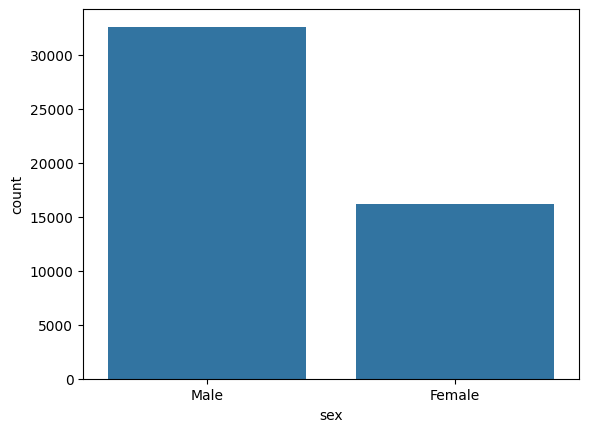

In [ ]:
sns.countplot( x = df['sex'])

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'State-gov'),
  Text(1, 0, 'Self-emp-not-inc'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, 'Self-emp-inc'),
  Text(6, 0, 'Without-pay'),
  Text(7, 0, 'Never-worked')])

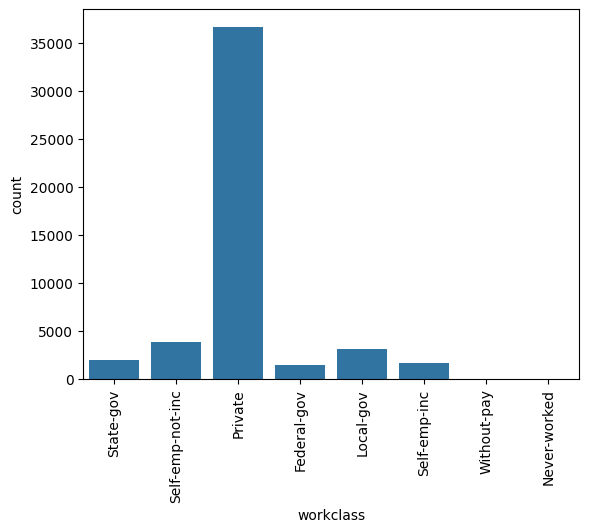

In [ ]:
sns.countplot( x = df['workclass'])
plt.xticks(rotation = 90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Adm-clerical'),
  Text(1, 0, 'Exec-managerial'),
  Text(2, 0, 'Handlers-cleaners'),
  Text(3, 0, 'Prof-specialty'),
  Text(4, 0, 'Other-service'),
  Text(5, 0, 'Sales'),
  Text(6, 0, 'Craft-repair'),
  Text(7, 0, 'Transport-moving'),
  Text(8, 0, 'Farming-fishing'),
  Text(9, 0, 'Machine-op-inspct'),
  Text(10, 0, 'Tech-support'),
  Text(11, 0, 'Protective-serv'),
  Text(12, 0, 'Armed-Forces'),
  Text(13, 0, 'Priv-house-serv')])

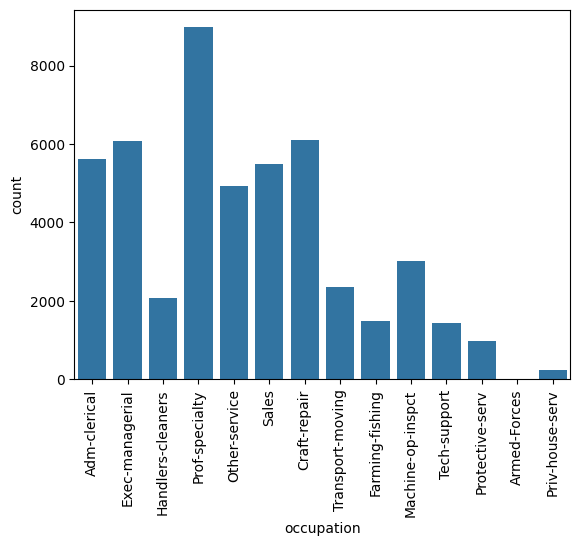

In [ ]:
sns.countplot(x = df['occupation'])
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, 'United-States'),
  Text(1, 0, 'Cuba'),
  Text(2, 0, 'Jamaica'),
  Text(3, 0, 'India'),
  Text(4, 0, '?'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'South'),
  Text(7, 0, 'Puerto-Rico'),
  Text(8, 0, 'Honduras'),
  Text(9, 0, 'England'),
  Text(10, 0, 'Canada'),
  Text(11, 0, 'Germany'),
  Text(12, 0, 'Iran'),
  Text(13, 0, 'Philippines'),
  Text(14, 0, 'Italy'),
  Text(15, 0, 'Poland'),
  Text(16, 0, 'Columbia'),
  Text(17, 0, 'Cambodia'),
  Text(18, 0, 'Thailand'),
  Text(19, 0, 'Ecuador'),
  Text(20, 0, 'Laos'),
  Text(21, 0, 'Taiwan'),
  Text(22, 0, 'Haiti'),
  Text(23, 0, 'Portugal'),
  Text(24, 0, 'Dominican-Republic'),
  Text(25, 0, 'El-Salvador'),
  Text(26, 0, 'France'),
  Text(27, 0, 'Guatemala'),
  Text(28, 0, 'China'),
  Text(

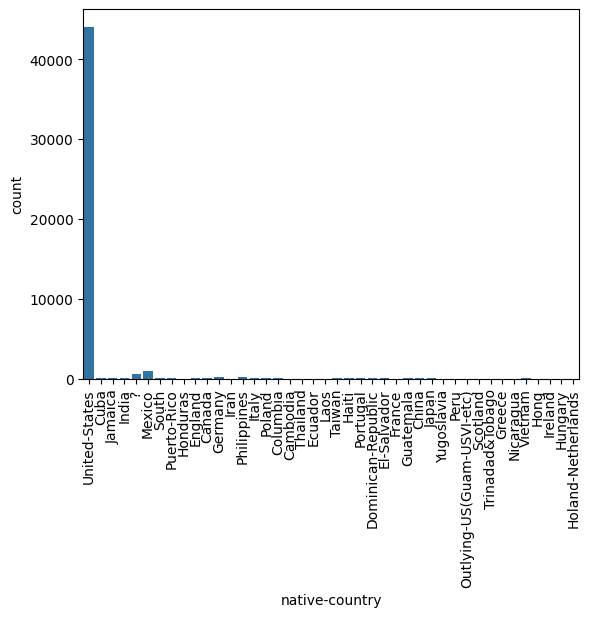

In [ ]:
sns.countplot(x = df['native-country'])
plt.xticks(rotation = 90)

<Axes: xlabel='income', ylabel='count'>

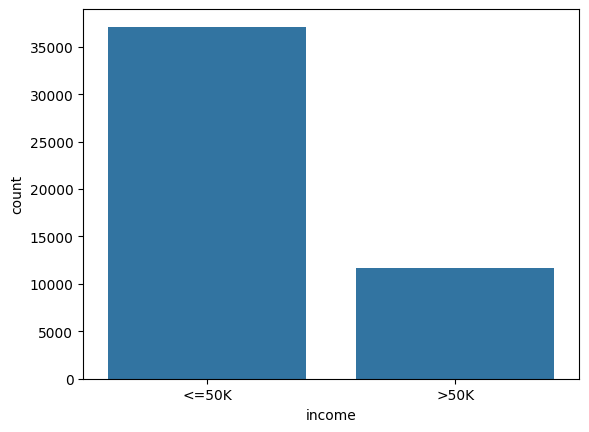

In [ ]:
sns.countplot(x = df['income'])

<Axes: >

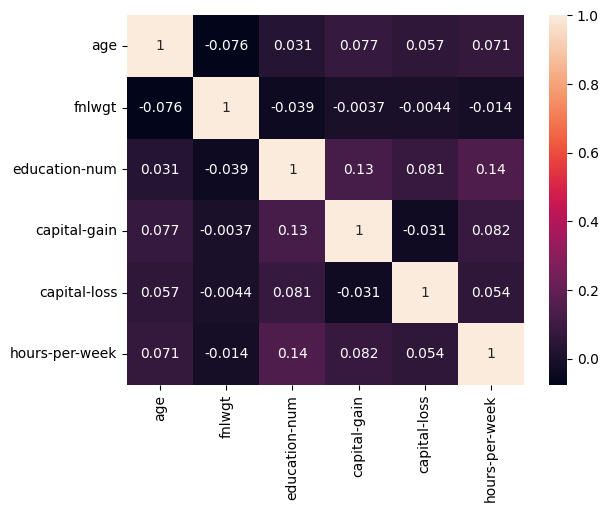

In [ ]:
sns.heatmap(df.corr(numeric_only= True),annot= True)


In [ ]:
df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=['Young', 'Early Career', 'Mid Career',
                'Senior', 'Pre-Retirement', 'Retirement']
    ).astype(str)

In [ ]:
df['capital_net'] = df['capital-gain'] - df['capital-loss']
print("  ✅ capital_net     — capital-gain minus capital-loss")

  ✅ capital_net     — capital-gain minus capital-loss


In [ ]:
df['has_capital'] = (
        (df['capital-gain'] > 0) | (df['capital-loss'] > 0)
    ).astype(int)
print("  ✅ has_capital     — 1 if any capital gain or loss")

  ✅ has_capital     — 1 if any capital gain or loss


In [ ]:
df['hours_category'] = pd.cut(
        df['hours-per-week'],
        bins=[0, 20, 34, 40, 55, 100],
        labels=['Part-time', 'Below Full', 'Full-time', 'Overtime', 'Extreme']
    ).astype(str)

In [ ]:
df['is_married'] = df['marital-status'].apply(
        lambda x: 1 if x in ['Married-civ-spouse', 'Married-AF-spouse'] else 0)

In [ ]:
edu_map = {
        'Preschool': 'Low',      '1st-4th': 'Low',      '5th-6th': 'Low',
        '7th-8th': 'Low',        '9th': 'Low',           '10th': 'Medium-Low',
        '11th': 'Medium-Low',    '12th': 'Medium-Low',   'HS-grad': 'Medium',
        'Some-college': 'Medium','Assoc-voc': 'Medium-High',
        'Assoc-acdm': 'Medium-High','Bachelors': 'High',
        'Masters': 'Very High',  'Prof-school': 'Very High',
        'Doctorate': 'Very High'
    }
df['education_level'] = df['education'].map(edu_map).fillna('Medium')

In [ ]:
df['work_life_ratio'] = (df['hours-per-week'] / 40.0).round(3)

In [ ]:
high_skill = ['Exec-managerial', 'Prof-specialty', 'Tech-support',
                  'Protective-serv']
df['is_high_skill'] = df['occupation'].apply(
        lambda x: 1 if x in high_skill else 0
    )

In [ ]:
df['age_x_edu'] = df['age'] * df['education-num']
print("  ✅ age_x_edu       — age × education_num interaction term")


  ✅ age_x_edu       — age × education_num interaction term


In [ ]:
print(f"\n✅ Shape after feature engineering: {df.shape}")


✅ Shape after feature engineering: (48789, 24)


In [ ]:
df['income_encoded'] = (df['income'] == '>50K').astype(int)
print(" Target encoded:  <=50K → 0  |  >50K → 1")

 Target encoded:  <=50K → 0  |  >50K → 1


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,age_group,capital_net,has_capital,hours_category,is_married,education_level,work_life_ratio,is_high_skill,age_x_edu,income_encoded
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,Mid Career,2174,1,Full-time,0,High,1.000,0,507,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,Senior,0,0,Part-time,1,High,0.325,1,650,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,Mid Career,0,0,Full-time,0,Medium,1.000,0,342,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,Senior,0,0,Full-time,1,Medium-Low,1.000,0,371,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,Early Career,0,0,Full-time,1,High,1.000,1,364,0


In [ ]:
DROP_COLS = [
    'income',
    'fnlwgt',
    'education',
    'native-country',
    'marital-status',
    'capital-gain',
    'capital-loss','race','education-num'
]
df_model = df.drop(columns=DROP_COLS)

In [ ]:
df_model.head()

,age,workclass,occupation,relationship,sex,hours-per-week,age_group,capital_net,has_capital,hours_category,is_married,education_level,work_life_ratio,is_high_skill,age_x_edu,income_encoded
0,39,State-gov,Adm-clerical,Not-in-family,Male,40,Mid Career,2174,1,Full-time,0,High,1.000,0,507,0
1,50,Self-emp-not-inc,Exec-managerial,Husband,Male,13,Senior,0,0,Part-time,1,High,0.325,1,650,0
2,38,Private,Handlers-cleaners,Not-in-family,Male,40,Mid Career,0,0,Full-time,0,Medium,1.000,0,342,0
3,53,Private,Handlers-cleaners,Husband,Male,40,Senior,0,0,Full-time,1,Medium-Low,1.000,0,371,0
4,28,Private,Prof-specialty,Wife,Female,40,Early Career,0,0,Full-time,1,High,1.000,1,364,0


In [ ]:
X = df_model.drop('income_encoded', axis=1)
y = df_model['income_encoded']

NUM_FEATURES = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
CAT_FEATURES = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n Numerical features ({len(NUM_FEATURES)}): {NUM_FEATURES}")
print(f" Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}")


 Numerical features (8): ['age', 'hours-per-week', 'capital_net', 'has_capital', 'is_married', 'work_life_ratio', 'is_high_skill', 'age_x_edu']
 Categorical features (7): ['workclass', 'occupation', 'relationship', 'sex', 'age_group', 'hours_category', 'education_level']


In [ ]:
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)

# Imbalance
from imblearn.over_sampling import SMOTE

# Explainability
import shap

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n Train : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")


 Train : 39,031 rows (80%)
Test  : 9,758 rows (20%)


In [ ]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
])

In [ ]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f"\n Preprocessing done")
print(f"   X_train_proc shape: {X_train_proc.shape}")
print(f"   X_test_proc  shape: {X_test_proc.shape}")


 Preprocessing done
   X_train_proc shape: (39031, 15)
   X_test_proc  shape: (9758, 15)


In [ ]:
before = pd.Series(y_train).value_counts()
print(f"   0 (<=50K): {before[0]:,}")
print(f"   1 (>50K) : {before[1]:,}")
print(f"   Ratio    : {before[0]/before[1]:.2f}:1  ← imbalanced!")

   0 (<=50K): 29,686
   1 (>50K) : 9,345
   Ratio    : 3.18:1  ← imbalanced!


In [ ]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f"\n Class distribution AFTER SMOTE:")
after = pd.Series(y_train_bal).value_counts()
print(f"   0 (<=50K): {after[0]:,}")
print(f"   1 (>50K) : {after[1]:,}")
print(f"   Ratio    : 1:1  ← balanced!")


 Class distribution AFTER SMOTE:
   0 (<=50K): 29,686
   1 (>50K) : 29,686
   Ratio    : 1:1  ← balanced!


In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    """Train, evaluate and return all metrics for a model."""
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = (
        model.predict_proba(X_te)[:, 1]
        if hasattr(model, 'predict_proba') else None
    )

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    # Cross-Validation
    cv     = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_f1  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=-1)

    print(f"\n{'─'*58}")
    print(f"   {name}")
    print(f"{'─'*58}")
    print(f"  Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision     : {prec:.4f}  ({prec*100:.2f}%)")
    print(f"  Recall        : {rec:.4f}  ({rec*100:.2f}%)")
    print(f"  F1 Score      : {f1:.4f}  ({f1*100:.2f}%)")
    if auc_score:
        print(f"  ROC-AUC       : {auc_score:.4f}  ({auc_score*100:.2f}%)")
    print(f"  CV F1 (5-fold): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
                                 target_names=['<=50K', '>50K'],
                                 zero_division=0))

    return {
        'name': name, 'model': model,
        'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc_score,
        'cv_mean': cv_f1.mean(), 'cv_std': cv_f1.std()
    }


results = []

In [ ]:
lr = LogisticRegression(
    C=1.0, max_iter=1000, solver='lbfgs',
    random_state=42
)
results.append(evaluate_model(
    "1. Logistic Regression",
    lr, X_train_bal, y_train_bal, X_test_proc, y_test
))


──────────────────────────────────────────────────────────
   1. Logistic Regression
──────────────────────────────────────────────────────────
  Accuracy      : 0.7973  (79.73%)
  Precision     : 0.5504  (55.04%)
  Recall        : 0.8365  (83.65%)
  F1 Score      : 0.6639  (66.39%)
  ROC-AUC       : 0.8964  (89.64%)
  CV F1 (5-fold): 0.8201 ± 0.0026

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      7422
        >50K       0.55      0.84      0.66      2336

    accuracy                           0.80      9758
   macro avg       0.74      0.81      0.76      9758
weighted avg       0.85      0.80      0.81      9758



In [ ]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)
results.append(evaluate_model(
    "2. Random Forest",
    rf, X_train_bal, y_train_bal, X_test_proc, y_test
))


──────────────────────────────────────────────────────────
   2. Random Forest
──────────────────────────────────────────────────────────
  Accuracy      : 0.8215  (82.15%)
  Precision     : 0.5907  (59.07%)
  Recall        : 0.8283  (82.83%)
  F1 Score      : 0.6896  (68.96%)
  ROC-AUC       : 0.9129  (91.29%)
  CV F1 (5-fold): 0.8787 ± 0.0016

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.82      0.87      7422
        >50K       0.59      0.83      0.69      2336

    accuracy                           0.82      9758
   macro avg       0.76      0.82      0.78      9758
weighted avg       0.85      0.82      0.83      9758



In [ ]:
svm = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, random_state=42
)
results.append(evaluate_model(
    "3. SVM (RBF Kernel)",
    svm,
    X_train_bal[:10000], y_train_bal[:10000],
    X_test_proc, y_test
))


──────────────────────────────────────────────────────────
   3. SVM (RBF Kernel)
──────────────────────────────────────────────────────────
  Accuracy      : 0.8469  (84.69%)
  Precision     : 0.7308  (73.08%)
  Recall        : 0.5706  (57.06%)
  F1 Score      : 0.6409  (64.09%)
  ROC-AUC       : 0.9017  (90.17%)
  CV F1 (5-fold): 0.6466 ± 0.0042

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      7422
        >50K       0.73      0.57      0.64      2336

    accuracy                           0.85      9758
   macro avg       0.80      0.75      0.77      9758
weighted avg       0.84      0.85      0.84      9758



In [ ]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
results.append(evaluate_model(
    "4. XGBoost",
    xgb, X_train_bal, y_train_bal, X_test_proc, y_test
))


──────────────────────────────────────────────────────────
   4. XGBoost
──────────────────────────────────────────────────────────
  Accuracy      : 0.8552  (85.52%)
  Precision     : 0.6813  (68.13%)
  Recall        : 0.7423  (74.23%)
  F1 Score      : 0.7105  (71.05%)
  ROC-AUC       : 0.9201  (92.01%)
  CV F1 (5-fold): 0.9028 ± 0.0038

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.92      0.89      0.90      7422
        >50K       0.68      0.74      0.71      2336

    accuracy                           0.86      9758
   macro avg       0.80      0.82      0.81      9758
weighted avg       0.86      0.86      0.86      9758



In [ ]:
gbc = GradientBoostingClassifier(
    n_estimators=200, max_depth=5,
    learning_rate=0.1, subsample=0.8,
    min_samples_split=5, random_state=42
)
results.append(evaluate_model(
    "5. Gradient Boosting",
    gbc, X_train_bal, y_train_bal, X_test_proc, y_test
))


──────────────────────────────────────────────────────────
   5. Gradient Boosting
──────────────────────────────────────────────────────────
  Accuracy      : 0.8522  (85.22%)
  Precision     : 0.6620  (66.20%)
  Recall        : 0.7821  (78.21%)
  F1 Score      : 0.7170  (71.70%)
  ROC-AUC       : 0.9235  (92.35%)
  CV F1 (5-fold): 0.8976 ± 0.0035

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.93      0.87      0.90      7422
        >50K       0.66      0.78      0.72      2336

    accuracy                           0.85      9758
   macro avg       0.79      0.83      0.81      9758
weighted avg       0.86      0.85      0.86      9758



In [ ]:
metrics_df = pd.DataFrame([{
    'Model':      r['name'],
    'Accuracy':   round(r['accuracy'],  4),
    'Precision':  round(r['precision'], 4),
    'Recall':     round(r['recall'],    4),
    'F1 Score':   round(r['f1'],        4),
    'ROC-AUC':    round(r['auc'],       4) if r['auc'] else None,
    'CV F1 Mean': round(r['cv_mean'],   4),
    'CV F1 Std':  round(r['cv_std'],    4),
} for r in results])

print("\n📊 Full Model Comparison Table:")
print(metrics_df.to_string(index=False))

best_row = metrics_df.loc[metrics_df['F1 Score'].idxmax()]
print(f"\n Best Model: {best_row['Model']}  (F1 = {best_row['F1 Score']})")


📊 Full Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV F1 Mean  CV F1 Std
1. Logistic Regression    0.7973     0.5504  0.8365    0.6639   0.8964      0.8201     0.0026
      2. Random Forest    0.8215     0.5907  0.8283    0.6896   0.9129      0.8787     0.0016
   3. SVM (RBF Kernel)    0.8469     0.7308  0.5706    0.6409   0.9017      0.6466     0.0042
            4. XGBoost    0.8552     0.6813  0.7423    0.7105   0.9201      0.9028     0.0038
  5. Gradient Boosting    0.8522     0.6620  0.7821    0.7170   0.9235      0.8976     0.0035

 Best Model: 5. Gradient Boosting  (F1 = 0.717)


In [ ]:
param_grid = {
    'n_estimators':     [200, 300],
    'max_depth':        [4, 6],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_tune = XGBClassifier(
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_tune, param_grid,
    cv=cv_strat, scoring='f1',
    n_jobs=-1, verbose=1, refit=True
)
grid_search.fit(X_train_bal, y_train_bal)

print(f"\n✅ Best Parameters : {grid_search.best_params_}")
print(f"✅ Best CV F1      : {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test_proc)
y_prob_tuned = best_xgb.predict_proba(X_test_proc)[:, 1]

print(f"\n🎯 Tuned XGBoost — TEST SET:")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"   F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"\n{classification_report(y_test, y_pred_tuned, target_names=['<=50K', '>50K'])}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
✅ Best CV F1      : 0.9028

🎯 Tuned XGBoost — TEST SET:
   Accuracy  : 0.8552
   F1 Score  : 0.7105
   ROC-AUC   : 0.9201

              precision    recall  f1-score   support

       <=50K       0.92      0.89      0.90      7422
        >50K       0.68      0.74      0.71      2336

    accuracy                           0.86      9758
   macro avg       0.80      0.82      0.81      9758
weighted avg       0.86      0.86      0.86      9758



In [ ]:
import joblib
import os


os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(best_xgb,          'models/gradient_boost_model.pkl')
joblib.dump(preprocessor,      'models/preprocessor.pkl')
joblib.dump(NUM_FEATURES,      'models/num_features.pkl')
joblib.dump(CAT_FEATURES,      'models/cat_features.pkl')

print("✅ Model saved      : models/gradient_boost_model.pkl")
print("✅ Preprocessor saved: models/preprocessor.pkl")